# Pathological Heating Scenarios: PDE vs CosmoTherm GF

Generates `pathological_heating_validation.pdf` (Figure 5 in paper).

Three stress-test heating histories: sinusoidal, wide Gaussian, and double power-law. Compares PDE, PDE GF table, and CosmoTherm GF.

In [1]:
import os
from pathlib import Path

# Ensure cargo is on PATH
cargo_bin = Path.home() / '.cargo' / 'bin'
if cargo_bin.is_dir() and str(cargo_bin) not in os.environ.get('PATH', ''):
    os.environ['PATH'] = str(cargo_bin) + os.pathsep + os.environ.get('PATH', '')

PROJECT_ROOT = Path.cwd().parent.parent
FIG_DIR = PROJECT_ROOT / 'notebooks' / 'figures'
FIG_DIR.mkdir(exist_ok=True)

import numpy as np
import matplotlib.pyplot as plt

from spectroxide import (
    g_bb, delta_n_to_delta_I, decompose_distortion, apply_style,
)
from spectroxide.solver import run_sweep
from spectroxide.greens_table import load_or_build_greens_table
from spectroxide.cosmotherm import load_greens_database, convolve_cosmotherm_gf
from spectroxide.plot_params import (
    C, DOUBLE_COL, LW, LW_THICK, LW_THIN, LEGEND_SIZE,
)

apply_style()

## Helpers

In [2]:
def strip_gbb(x, delta_n):
    """NC strip: subtract G_bb so int x^2 Dn dx = 0."""
    gbb = g_bb(x)
    alpha = np.trapz(x**2 * delta_n, x) / np.trapz(x**2 * gbb, x)
    return delta_n - alpha * gbb, alpha


def rms_percent(nu1, di1, nu2, di2, nu_lo=30, nu_hi=800):
    """RMS % between two spectra, interpolated to common grid."""
    mask = (nu1 >= nu_lo) & (nu1 <= nu_hi)
    di2_interp = np.interp(nu1, nu2, di2)
    ref = np.max(np.abs(di2_interp[mask]))
    if ref < 1e-50:
        return np.nan
    return np.sqrt(np.mean((di1[mask] - di2_interp[mask])**2)) / ref * 100

## Define pathological heating functions

In [3]:
k_sin = 2 * np.pi / 5e4
A_sin = 5e-10

def dq_dz_sin(z):
    if z < 1e3 or z > 5e5:
        return 0.0
    return A_sin * np.sin(k_sin * (1 + z))

z0_gauss = 8e4
sigma_gauss = 4e4
A_gauss = 1e-5 / (sigma_gauss * np.sqrt(2 * np.pi))

def dq_dz_gauss(z):
    return A_gauss * np.exp(-0.5 * ((z - z0_gauss) / sigma_gauss)**2)

z_c = 3e5
A_dpl = 1e-5 / (6 * z_c**4)

def dq_dz_dpl(z):
    return A_dpl * z**3 * np.exp(-z / z_c)

scenarios = [
    ("Sinusoidal heating/cooling",              dq_dz_sin,   C["red"]),
    (r"Wide Gaussian",   dq_dz_gauss, C["blue"]),
    (r"Peaked power-law",           dq_dz_dpl,   C["orange"]),
]

## Load Green's function tables

In [4]:
print("Loading PDE GF table (production quality)...", flush=True)
_HQ_CACHE = Path.home() / ".spectroxide" / "greens_table_hq.npz"
heat_table = load_or_build_greens_table(
    cache_path=_HQ_CACHE,
    # rebuild=True,
    z_injections=np.logspace(np.log10(1e3), np.log10(5e6), 200),
    n_points=4000,
    n_x=4000,
    x_min=0.005,
    x_max=40.0,
    z_end=1001.0,
    dy_max=0.005,
    timeout=3600,
)
print(f"  {len(heat_table.z_h)} redshifts, {len(heat_table.x)} freq pts")

print("Loading CosmoTherm GF database...", flush=True)
z_h_ct, x_ct, g_th_ct = load_greens_database()
print(f"  {len(z_h_ct)} redshifts x {len(x_ct)} frequencies")

Loading PDE GF table (production quality)...
  200 redshifts, 4000 freq pts
Loading CosmoTherm GF database...
  118 redshifts x 4190 frequencies


## Run PDE, GF table, and CosmoTherm GF for each scenario

In [5]:
x_obs = np.linspace(0.1, 25, 1000)
NU_TO_X = 1.0 / 56.786  # x = nu_GHz * NU_TO_X

results = []
for name, dq_fn, color in scenarios:
    print(f"\n=== {name} ===")

    # dy_max=0.005 (paper-figure value, tighter than the post-baa28db
    # default 0.02): fine z-structure in the sinusoidal/peaked-power-law
    # scenarios needs the tighter step.
    print("  Running PDE...", flush=True)
    pde_result = run_sweep(
        dq_dz=dq_fn,
        method="pde",
        z_min=1e3,
        z_max=3e6,
        z_end=100.0,
        n_z=10000,
        n_points=8000,
        number_conserving=True,
        dy_max=0.005,
        timeout=1800,
    )
    x_pde = np.array(pde_result["results"][0]["x"])
    dn_pde = np.array(pde_result["results"][0]["delta_n"])
    dn_pde_nc, alpha_pde = strip_gbb(x_pde, dn_pde)
    nu_pde, di_pde = delta_n_to_delta_I(x_pde, dn_pde_nc)
    dec_pde = decompose_distortion(x_pde, dn_pde_nc)
    print(f"  PDE: mu={dec_pde['mu']:.3e}, y={dec_pde['y']:.3e}")

    # --- PDE GF Table (library convolution on cache's x grid) ---
    print("  GF table convolution...", flush=True)
    dn_tab = heat_table.distortion_from_heating(heat_table.x, dq_fn, 1e3, 3e6, n_z=5000)
    dn_tab_nc, alpha_tab = strip_gbb(heat_table.x, dn_tab)
    nu_tab, di_tab = delta_n_to_delta_I(heat_table.x, dn_tab_nc)
    dec_tab = decompose_distortion(heat_table.x, dn_tab_nc)
    print(f"  Table: mu={dec_tab['mu']:.3e}, y={dec_tab['y']:.3e}")

    # --- CosmoTherm GF ---
    print("  CosmoTherm GF convolution...", flush=True)
    x_ct_out, di_ct_jy = convolve_cosmotherm_gf(
        z_h_ct, x_ct, g_th_ct, dq_fn,
        z_min=1e3, z_max=3e6, n_z=5000,
    )
    _K_B = 1.380_649e-23
    _H_PL = 6.626_070_15e-34
    _T_CMB = 2.726
    nu_ct = x_ct_out * _K_B * _T_CMB / _H_PL / 1e9  # GHz

    rms_tab = rms_percent(nu_tab, di_tab, nu_pde, di_pde)
    rms_ct = rms_percent(nu_ct, di_ct_jy, nu_pde, di_pde)
    print(f"  RMS vs PDE: table={rms_tab:.1f}%, CosmoTherm={rms_ct:.1f}%")

    results.append({
        "name": name, "color": color,
        "nu_pde": nu_pde, "di_pde": di_pde,
        "nu_tab": nu_tab, "di_tab": di_tab,
        "x_ct": x_ct_out, "di_ct": di_ct_jy,
        "rms_tab": rms_tab, "rms_ct": rms_ct,
    })



=== Sinusoidal heating/cooling ===
  Running PDE...
  PDE: mu=-5.416e-06, y=9.230e-07
  GF table convolution...
  Table: mu=-5.445e-06, y=9.321e-07
  CosmoTherm GF convolution...
  RMS vs PDE: table=0.4%, CosmoTherm=0.5%

=== Wide Gaussian ===
  Running PDE...
  PDE: mu=5.626e-06, y=3.895e-06
  GF table convolution...
  Table: mu=5.650e-06, y=3.888e-06
  CosmoTherm GF convolution...
  RMS vs PDE: table=0.1%, CosmoTherm=0.1%

=== Peaked power-law ===
  Running PDE...
  PDE: mu=9.915e-06, y=4.257e-08
  GF table convolution...
  Table: mu=1.000e-05, y=4.278e-08
  CosmoTherm GF convolution...
  RMS vs PDE: table=0.4%, CosmoTherm=0.7%


## Figure

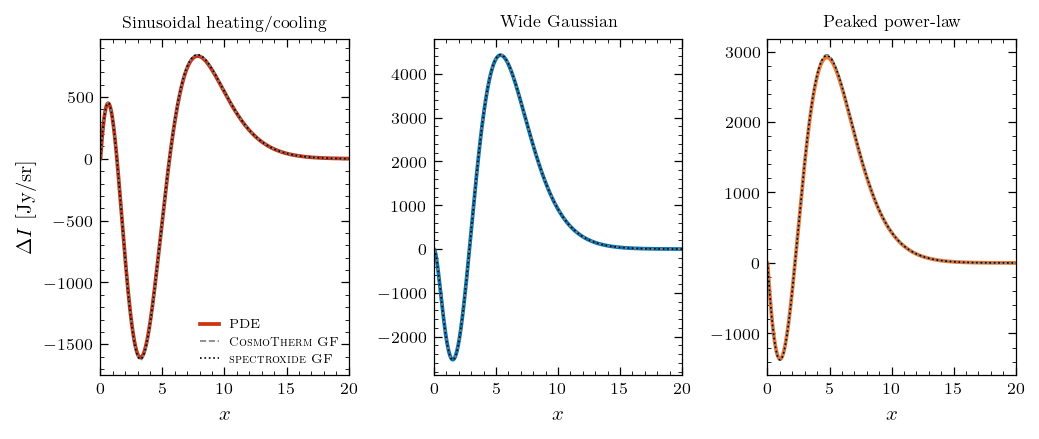

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(DOUBLE_COL, 3.0))

for idx, hr in enumerate(results):
    ax = axes[idx]
    ax.plot(hr["nu_pde"] * NU_TO_X, hr["di_pde"], color=hr["color"], lw=LW_THICK, label="PDE")
    ax.plot(hr["x_ct"], hr["di_ct"], color="gray", lw=LW_THIN, ls="--", label=r"\textsc{CosmoTherm} GF")
    ax.plot(hr["nu_tab"] * NU_TO_X, hr["di_tab"], color="k", lw=LW_THIN, ls=":", label=r"\textsc{spectroxide} GF")
    ax.set_xlabel(r"$x$")
    ax.set_title(hr["name"], fontsize=8)
    ax.set_xlim(0, 20)
    if idx == 0:
        ax.set_ylabel(r"$\Delta I$ [Jy/sr]")
        ax.legend(fontsize=LEGEND_SIZE - 1, loc='best')

plt.tight_layout()
fig.savefig(FIG_DIR / 'pathological_heating_validation.pdf', bbox_inches='tight')
plt.show()